In [1]:
from bdschism.ccf_gate_height import ccf_gate, sffpx_level
import datetime as dtm
import os
import pandas as pd
import datetime as dtm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# update to work for other flux files

In [2]:
def sffpx_level_alt(sdate, edate, sf_data_repo, margin=dtm.timedelta(days=30)):
    from dms_datastore.read_multi import read_ts_repo, infer_source_priority
    s1 = dtm.datetime.strptime(sdate, "%Y-%m-%d")
    s2 = dtm.datetime.strptime(edate, "%Y-%m-%d")
    ts_df = read_ts_repo("sffpx", "elev", repo=sf_data_repo, src_priority="infer",start=s1-2*margin, end=s2+2*margin)
    ts_df_pred = read_ts_repo(
        "sffpx", "predictions", repo=sf_data_repo, src_priority="infer",
    start=s1-2*margin, end=s2+2*margin)
    # Check if missing values and replace with predicted values
    if ts_df.isnull().any().any():
        print("Missing values detected in SFFPX data. Replacing with predicted values.")
        ts_df = ts_df.combine_first(ts_df_pred)

    # Shift for SCHISM time zone
    shift_h = dtm.timedelta(hours=8.5)
    position_shift = int(shift_h / ts_df.index.freq)
    ts_df = ts_df.shift(position_shift)
    ts_df = ts_df.loc[s1 - margin : s2 + margin]
    ts_df.columns = ["elev"]

    return ts_df

In [3]:
model_start = "2018-08-14"
model_end = "2018-08-20"
# #model_end = "2021-10-01"
# s1 = dtm.datetime.strptime(model_start, "%Y-%m-%d")
# s2 = dtm.datetime.strptime(model_end, "%Y-%m-%d")
# margin=dtm.timedelta(days=30)

#dated_case_dir="/home/jisrael/BayDeltaSCHISM/data/time_history/"
#for DCP
export_file = "/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_s0065.th.ported"
#os.path.join(dated_case_dir, "flux.th")
#Lily sent me the astro_file
astro_file = "/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/oh4_15min_predicted_10y_01_25.out" #"/scratch/projects/dsp/updated_schism_202602/th_files/prepro_files/oh4_15min_predicted_10y_01_25.out"
sf_data_repo = "/expanse/lustre/scratch/jisrael/temp_project/validation_data/screened/" #"/scratch/nasbdo/modeling_data/repo/continuous/screened/"
plot = True


In [4]:
#try Jon's version again
# sffpx_elev=sffpx_level(model_start, model_end, sf_data_repo)
# sffpx_elev
sffpx_elev=sffpx_level_alt(model_start, model_end, sf_data_repo)

In [5]:
sffpx_elev

,elev
2018-07-15 00:00:00,1.326
2018-07-15 00:06:00,1.278
2018-07-15 00:12:00,1.249
2018-07-15 00:18:00,1.218
2018-07-15 00:24:00,1.186
...,...
2018-09-18 23:36:00,1.188
2018-09-18 23:42:00,1.200
2018-09-18 23:48:00,1.219
2018-09-18 23:54:00,1.227


The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to /home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_DCP_dated_short_fixed.th


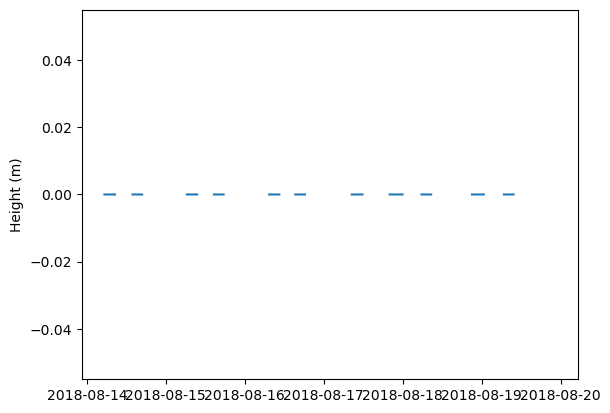

In [7]:
# this version doesn't use start and end bc its in sffpx
dest='/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_DCP_dated_short_fixed.th'
#scenario_files/DCP/ccfb_DCP_dated_fixed.th'
plot=True
save_intermediate=True
ccf_gate(model_start,model_end,dest,astro_file,export_file,sffpx_elev,plot,save_intermediate)
# sdate,edate,dest,astro_file,export_file,sffpx_elev,plot=False,save_intermediate=False

# my function

In [5]:
def ccf_gate_alt(sffpx_elev,dest,export_file,astrofile,plot):
    from vtools.functions.unit_conversions import M2FT, FT2M
    from vtools.functions.filter import cosine_lanczos
    from bdschism.ccf_gate_height import remove_continuous_duplicates
    from bdschism.ccf_gate_height import get_export_ts, gen_prio_for_varying_exports, gen_gate_height
    import matplotlib.pyplot as plt

    # from ccf_gate
    oneday = dtm.timedelta(days=1)
    #process_height isn't working
    margin = dtm.timedelta(days=3)
    export_ts, cvp_ts = get_export_ts(s1 - margin, s2 + margin, export_file)
    export_ts_daily_average = export_ts.resample("D").mean()
    inside_level0 = 2.12  # in feet
    dt = dtm.timedelta(minutes=2)
    priority, max_height = gen_prio_for_varying_exports(
    sffpx_elev, export_ts_daily_average)
    prio_dir = "./prio_ts"
    if not os.path.exists(prio_dir):
        os.makedirs(prio_dir)
    full_path = os.path.abspath(os.path.join(prio_dir,"priority.csv"))
    priority.to_csv(full_path,sep=" ",
        header=True,
        float_format="%.3f",
        date_format="%Y-%m-%dT%H:%M"
    )
    
    sffpx = sffpx_elev * M2FT
    sffpx_subtide = cosine_lanczos(sffpx_elev, cutoff_period="40h")
    #the filtering step we lose a bit on each end
    sffpx_subtide = sffpx_subtide.resample("15min").ffill()
    
    # from predict_oh4_level
    oh4_astro_raw = pd.read_csv(
        astro_file,
        header=None,
        #sep=r"\s+",
        sep=r'\s{2,}',
        names=["datetime", "value"],
        engine="python",
    )
    oh4_astro_raw["datetime"] = pd.to_datetime(
        oh4_astro_raw["datetime"], errors="coerce", format="%Y-%m-%d %H:%M"
    )
    oh4_astro = (
    oh4_astro_raw.dropna(subset=["datetime"])
    .set_index("datetime")["value"]
    .astype(float)
    .asfreq("15min"))
    oh4_sub_predicted = sffpx_subtide * 0.9620 + 1.1513
    best_shift = -10
    oh4_sub_predicted = oh4_sub_predicted.shift(-best_shift).squeeze()
    oh4_predicted = oh4_sub_predicted + oh4_astro - oh4_sub_predicted.mean()

    sim_gate_height, zin_df = gen_gate_height(
        export_ts, priority, max_height, oh4_predicted, cvp_ts, inside_level0, s1, s2, dt
    )
    height=sim_gate_height
    height_t = remove_continuous_duplicates(height, height.columns.tolist()[0])
    height_t = height_t * FT2M
    height_t.index.name = "datetime"
    height_t.columns = ["height"]
    dlen = len(height_t)
    height_t.insert(0, "install", dlen * [1])
    height_t.insert(1, "ndup", dlen * [5])
    height_t.insert(2, "op_down", dlen * [1.0])
    height_t.insert(3, "op_up", dlen * [0.0])
    height_t.insert(4, "elev", dlen * [-4.0244])
    height_t.insert(5, "width", dlen * [6.096])
    
    print(f"Saving predicted gate height file to {dest}")
    height_t[s1 : s2 + oneday].to_csv(
        dest,
        sep=" ",
        header=True,
        float_format="%.3f",
        date_format="%Y-%m-%dT%H:%M",
    )
    if plot:
        fig, (ax1) = plt.subplots(1, 1)
        lsyn = ax1.step(
            height_t.index,
            height_t["height"],
            where="post",
            label="ccfb gate height predicted",
        )
        ax1.set_ylabel("Height (m)")

    return

In [6]:
sffpx_elev=sffpx_level_alt(model_start, model_end, sf_data_repo)

The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to /home/jisrael/Savio_scratch_back_up/scenario_files/DCP/ccfb_DCP_dated_short.th


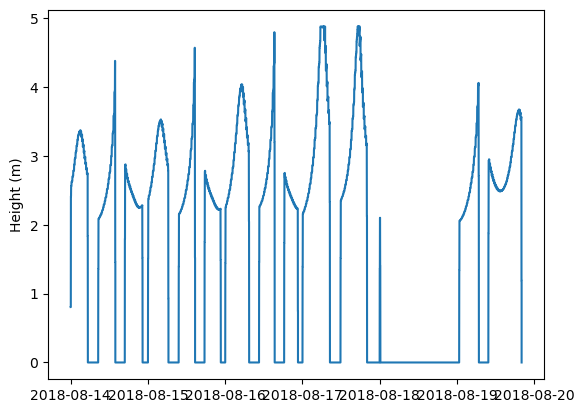

In [7]:
# this version doesn't use start and end bc its in sffpx
dest='/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/ccfb_DCP_dated_short.th'
plot=True
ccf_gate_alt(sffpx_elev,dest,export_file,astro_file,plot)

In [8]:
# plot the tunnel export file with the historical for swp and cvp

In [9]:
flux_tunnel_ts=pd.read_csv(export_file,sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
flux_tunnel_ts

/scratch/jisrael/job_47443407/ipykernel_3136934/4208044352.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  flux_tunnel_ts=pd.read_csv(export_file,sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])


,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2017-01-01 00:00:00,-0.214,2.1062,-0.0625,233.356293,123.780701,-136.383194,-33.111500,-200.514206,-379.923798,-1623.443481,-20.559999,-0.001,2.7747,-3.370,2.476
2017-01-01 00:15:00,-0.220,2.1091,-0.0626,233.915207,123.848999,-136.626205,-33.183899,-200.815201,-380.186188,-1624.583496,-21.120001,-0.001,2.7765,-3.370,2.483
2017-01-01 00:30:00,-0.220,2.1120,-0.0628,234.465698,123.916199,-136.868805,-33.256100,-201.115601,-380.447998,-1625.721069,-19.570000,-0.001,2.7784,-3.341,2.489
2017-01-01 00:45:00,-0.214,2.1148,-0.0629,235.007996,123.982300,-137.110901,-33.328201,-201.415405,-380.709198,-1626.856445,-20.870001,-0.001,2.7802,-3.370,2.493
2017-01-01 01:00:00,-0.207,2.1177,-0.0630,235.542297,124.047600,-137.352493,-33.400101,-201.714600,-380.969910,-1627.989258,-15.520000,-0.001,2.7821,-3.370,2.497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 23:00:00,-7.136,1.7250,0.0000,0.140000,66.184998,-61.730999,-0.000000,-31.152000,-142.716995,-699.929993,-46.040001,-0.001,0.3960,-11.157,0.000
2021-12-31 23:15:00,-7.136,1.7260,0.0000,0.140000,65.134003,-61.730999,-0.000000,-31.149000,-143.565994,-699.208984,-45.509998,-0.001,0.3960,-11.072,0.000
2021-12-31 23:30:00,-7.136,1.7260,0.0000,0.140000,63.902000,-61.730999,-0.000000,-31.146000,-143.565994,-699.614990,-45.250000,-0.001,0.3960,-11.100,0.000


In [10]:
flux_ts=pd.read_csv("/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th",sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
flux_ts

/scratch/jisrael/job_47443407/ipykernel_3136934/3504235583.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  flux_ts=pd.read_csv("/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th",sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])


,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2006-10-01 00:00:00,-0.62,0.67,4.52,262.320007,120.830002,-94.860001,-0.0,-25.780001,-72.769997,-329.829987,0.690000,-0.00,2.48,-0.01,0.00
2006-10-01 00:15:00,-0.62,0.67,4.52,263.239990,120.820000,-94.860001,-0.0,-25.730000,-71.919998,-329.890015,-4.620000,-0.00,2.46,-0.01,0.00
2006-10-01 00:30:00,-0.62,0.66,4.52,263.410004,120.820000,-95.430000,-0.0,-25.690001,-73.339996,-330.239990,-8.100000,-0.00,2.46,-0.01,0.00
2006-10-01 00:45:00,-0.62,0.66,4.52,263.390015,120.820000,-94.860001,-0.0,-25.660000,-73.910004,-330.299988,-9.660000,-0.00,2.45,-0.01,0.00
2006-10-01 01:00:00,-0.62,0.66,4.52,263.350006,120.820000,-94.860001,-0.0,-25.629999,-73.910004,-330.649994,-10.650000,-0.00,2.45,-0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14 23:00:00,-0.76,0.00,3.40,1.010000,98.879997,-79.940002,-0.0,-76.169998,-144.699997,-1716.310059,-113.269997,-9.06,0.54,-5.10,1.17
2026-01-14 23:15:00,-0.74,0.00,3.42,3.000000,98.870003,-79.919998,-0.0,-76.180000,-144.699997,-1716.869995,-113.269997,-8.50,0.55,-5.04,1.18
2026-01-14 23:30:00,-0.74,0.00,3.44,7.780000,98.860001,-79.900002,-0.0,-76.180000,-144.130005,-1716.869995,-113.269997,-8.50,0.57,-5.10,1.20


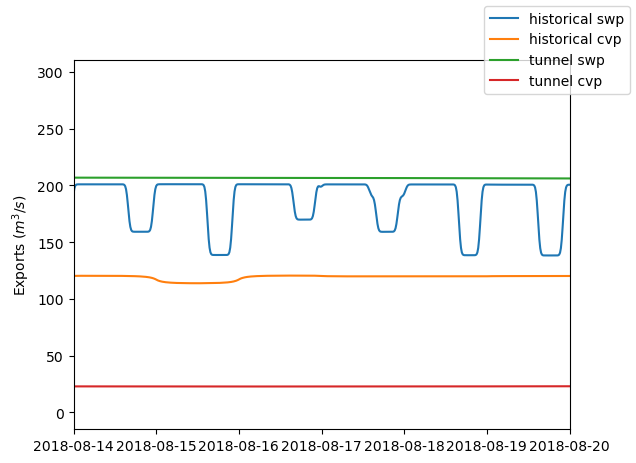

In [11]:
fig, ax = plt.subplots()
ax.plot(flux_ts.swp,label='historical swp')
ax.plot(flux_ts.cvp,label='historical cvp')

ax.plot(flux_tunnel_ts.swp, label='tunnel swp')
ax.plot(flux_tunnel_ts.cvp, label='tunnel cvp')
ax.set_xlim(dtm.datetime(2018,8,14),dtm.datetime(2018,8,20))
ax.set_ylabel(r'Exports $(m^3/s)$')
fig.legend()
fig.savefig('tunnel_calsim_exports.png')           

In [12]:
sffpx_elev

,elev
2018-07-15 00:00:00,1.326
2018-07-15 00:06:00,1.278
2018-07-15 00:12:00,1.249
2018-07-15 00:18:00,1.218
2018-07-15 00:24:00,1.186
...,...
2018-09-18 23:36:00,1.188
2018-09-18 23:42:00,1.200
2018-09-18 23:48:00,1.219
2018-09-18 23:54:00,1.227


In [13]:
dest='/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/ccfb_DCP_dated.th'
dcp=pd.read_csv(dest, sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])


/scratch/jisrael/job_47443407/ipykernel_3136934/4012574720.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  dcp=pd.read_csv(dest, sep=r'\s',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])


In [14]:
dcp

,install,ndup,op_down,op_up,elev,width,height
datetime,,,,,,,
2018-08-14 00:00:00,1.0,5.0,1.0,0.0,-4.024,6.096,0.802
2018-08-14 00:02:00,1.0,5.0,1.0,0.0,-4.024,6.096,1.604
2018-08-14 00:04:00,1.0,5.0,1.0,0.0,-4.024,6.096,2.406
2018-08-14 00:06:00,1.0,5.0,1.0,0.0,-4.024,6.096,2.542
2018-08-14 00:08:00,1.0,5.0,1.0,0.0,-4.024,6.096,2.550
...,...,...,...,...,...,...,...
2021-09-30 02:40:00,1.0,5.0,1.0,0.0,-4.024,6.096,1.016
2021-09-30 02:42:00,1.0,5.0,1.0,0.0,-4.024,6.096,1.524
2021-09-30 05:28:00,1.0,5.0,1.0,0.0,-4.024,6.096,1.016


In [15]:
ccfb_hist=pd.read_csv("/home/jisrael/BayDeltaSCHISM/data/time_history/ccfb_gate.th",sep=r'\s',parse_dates=["datetime"],dtype=np.float32,on_bad_lines='skip').set_index(["datetime"])
ccfb_hist

/scratch/jisrael/job_47443407/ipykernel_3136934/350503219.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ccfb_hist=pd.read_csv("/home/jisrael/BayDeltaSCHISM/data/time_history/ccfb_gate.th",sep=r'\s',parse_dates=["datetime"],dtype=np.float32,on_bad_lines='skip').set_index(["datetime"])


,install,ndup,op_down,op_up,elev,width,height
datetime,,,,,,,
1997-10-01 00:00:00,1.0,5.0,1.0,0.0,-4.0244,6.096,2.270
1997-10-01 10:45:00,1.0,5.0,1.0,0.0,-4.0244,6.096,0.500
1997-10-01 10:55:00,1.0,5.0,1.0,0.0,-4.0244,6.096,0.100
1997-10-01 11:05:00,1.0,0.0,1.0,0.0,-4.0244,6.096,0.000
1997-10-01 18:35:00,1.0,5.0,1.0,0.0,-4.0244,6.096,0.100
...,...,...,...,...,...,...,...
2026-01-19 10:04:00,1.0,5.0,1.0,0.0,-4.0244,6.096,1.044
2026-01-19 10:06:00,1.0,5.0,1.0,0.0,-4.0244,6.096,0.530
2026-01-19 10:08:00,1.0,2.0,1.0,0.0,-4.0244,6.096,0.238


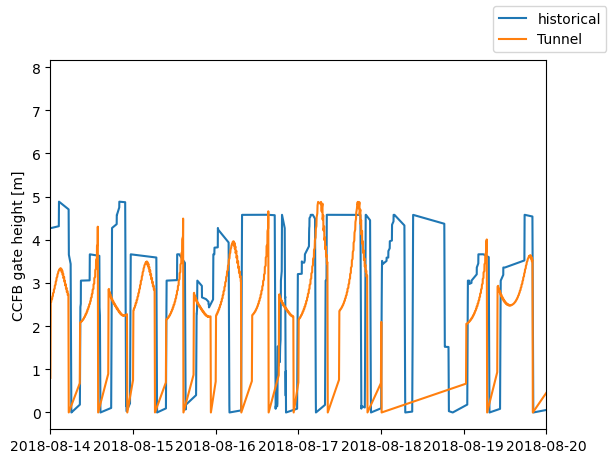

In [16]:
fig, ax = plt.subplots()
ax.plot(ccfb_hist.height,label='historical')
ax.plot(dcp.height,label='Tunnel')
ax.set_xlim(dtm.datetime(2018,8,14),dtm.datetime(2018,8,20))
fig.legend()
ax.set_ylabel('CCFB gate height [m]')
fig.savefig('tunnel_calsim_gate_height.png')  

In [21]:
# make a shortened version of the ported flux file for Jon
tunnel_ts_short=flux_tunnel_ts.loc[dtm.datetime(2018,8,14):dtm.datetime(2018,8,20)]
tunnel_ts_short.to_csv('flux_s0065_trimmed.th.ported')

In [29]:
test=dcp.columns.to_list()
print(test)
test2=np.concatenate((['e_time'],test))
print(test2)

['install', 'ndup', 'op_down', 'op_up', 'elev', 'width', 'height']
['e_time' 'install' 'ndup' 'op_down' 'op_up' 'elev' 'width' 'height']


In [30]:
np.concatenate((['e_time'],dcp.columns.to_list()))

array(['e_time', 'install', 'ndup', 'op_down', 'op_up', 'elev', 'width',
       'height'], dtype='<U7')

In [37]:
# add the file I modified 
col_names=np.concatenate((['e_time'],dcp.columns.to_list()))
dcp_mod=pd.read_csv("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/ccfb_DCP_mod.th",sep=r'\s+',dtype=np.float32,header=None,names=col_names)
dcp_mod

,e_time,install,ndup,op_down,op_up,elev,width,height
0,0.0,1.0,5.0,1.0,0.0,-4.024,6.096,0.802
1,120.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.604
2,240.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.406
3,360.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.542
4,480.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.550
...,...,...,...,...,...,...,...,...
220192,98764800.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.016
220193,98764920.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.524
220194,98774880.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.016
220195,98775000.0,1.0,5.0,1.0,0.0,-4.024,6.096,0.508


In [38]:
# Add in the number of seconds elapsed @ our chosen timestep
timedelta = [pd.Timedelta(i, unit = 's') for i in dcp_mod.e_time]
timestamp = [pd.to_datetime("08-14-2018 00:00") + i for i in timedelta]
    
dcp_mod["datetime"] = timestamp
dcp_mod.set_index(dcp_mod["datetime"],inplace=True)
dcp_mod

,e_time,install,ndup,op_down,op_up,elev,width,height,datetime
0,0.0,1.0,5.0,1.0,0.0,-4.024,6.096,0.802,2018-08-14 00:00:00
1,120.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.604,2018-08-14 00:02:00
2,240.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.406,2018-08-14 00:04:00
3,360.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.542,2018-08-14 00:06:00
4,480.0,1.0,5.0,1.0,0.0,-4.024,6.096,2.550,2018-08-14 00:08:00
...,...,...,...,...,...,...,...,...,...
220192,98764800.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.016,2021-09-30 02:40:00
220193,98764920.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.524,2021-09-30 02:42:00
220194,98774880.0,1.0,5.0,1.0,0.0,-4.024,6.096,1.016,2021-09-30 05:28:00
220195,98775000.0,1.0,5.0,1.0,0.0,-4.024,6.096,0.508,2021-09-30 05:30:00


Text(0, 0.5, 'CCFB gate height [m]')

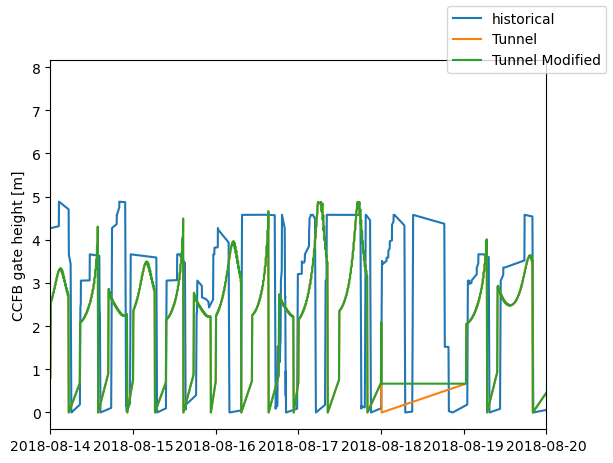

In [40]:
fig, ax = plt.subplots()
ax.plot(ccfb_hist.height,label='historical')
ax.plot(dcp.height,label='Tunnel')
ax.plot(dcp_mod.height,label='Tunnel Modified')
ax.set_xlim(dtm.datetime(2018,8,14),dtm.datetime(2018,8,20))
fig.legend()
ax.set_ylabel('CCFB gate height [m]')


Text(0, 0.5, 'CCFB gate height [m]')

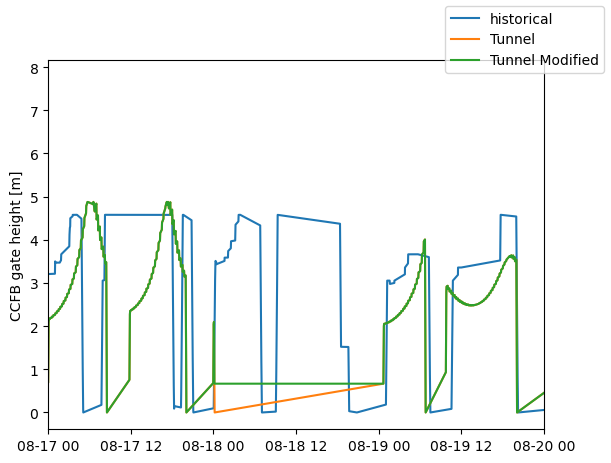

In [42]:
fig, ax = plt.subplots()
ax.plot(ccfb_hist.height,label='historical')
ax.plot(dcp.height,label='Tunnel')
ax.plot(dcp_mod.height,label='Tunnel Modified')
ax.set_xlim(dtm.datetime(2018,8,17),dtm.datetime(2018,8,20))
fig.legend()
ax.set_ylabel('CCFB gate height [m]')


In [16]:
#open the one from just now is it the same
dcp2=pd.read_csv('~/Savio_scratch_back_up/scenario_files/DCP/ccfb_DCP_dated.th', sep=r'\s')

/scratch/jisrael/job_47346184/ipykernel_3733888/615027647.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  dcp2=pd.read_csv('~/Savio_scratch_back_up/scenario_files/DCP/ccfb_DCP_dated.th', sep=r'\s')


(np.float64(17762.206944444446), np.float64(231205.8))

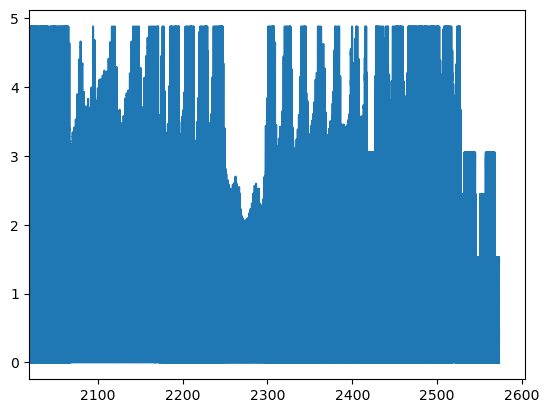

In [17]:
fig, ax = plt.subplots()
ax.plot(dcp2.height)
ax.set_xlim(pd.to_datetime('2018-08-19T04:58'))

In [ ]:
# this version doesn't use start and end bc its in sffpx
dest='/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/ccfb_DCP_dated.th'
plot=True
ccf_gate_alt(sffpx_elev,dest,export_file,astro_file,plot)

The input export dt is Daily
Making priorities from tide


The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to ./ccfb_dated_2.th


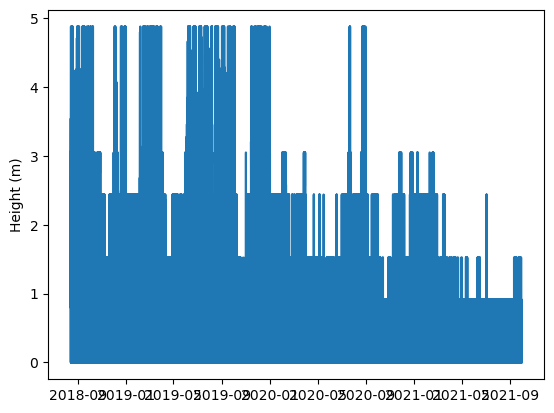

In [8]:
# this version doesn't use start and end bc its in sffpx
dest_org='./ccfb_dated_2.th'
export_file_org=os.path.join(dated_case_dir, "flux.th")
plot=True
ccf_gate_alt(sffpx_elev,dest_org,export_file_org,astro_file,plot)

# try the ccf gate function that Jon updated, pulled 03/13/2026, still can't read the astro file

In [8]:
ccf_gate(
      model_start,
      model_end,
      "./ccfb_gate_DCP_dated.th",
      astro_file,
      export_file,
      sffpx_elev,
      plot=True,
)

The input export dt is Daily
Making priorities from tide


DateParseError: Unknown datetime string format, unable to parse: 2001-01-01 00:00        4.3886

# debug ccf gate function

In [24]:
from bdschism.ccf_gate_height import process_height

In [25]:
oneday = dtm.timedelta(days=1)
height, zin = process_height(s1, s2, export_file, astro_file, sffpx_elev)

The input export dt is Daily
Making priorities from tide


DateParseError: Unknown datetime string format, unable to parse: 2001-01-01 00:00        4.3886

In [29]:
height

NameError: name 'height' is not defined

In [30]:
# why are there nans here?
from bdschism.ccf_gate_height import get_export_ts, gen_prio_for_varying_exports, predict_oh4_level, gen_gate_height

In [31]:
margin = dtm.timedelta(days=3)
export_ts, cvp_ts = get_export_ts(s1 - margin, s2 + margin, export_file)
export_ts_daily_average = export_ts.resample("D").mean()
inside_level0 = 2.12  # in feet
dt = dtm.timedelta(minutes=2)
#export_ts_daily_average
## above here seems fine 

In [32]:
priority, max_height = gen_prio_for_varying_exports(
    sffpx_elev, export_ts_daily_average
)
#max_height
## above here seems fine

The input export dt is Daily
Making priorities from tide


In [33]:
prio_dir = "./prio_ts"
if not os.path.exists(prio_dir):
    os.makedirs(prio_dir)
full_path = os.path.abspath(os.path.join(prio_dir,"priority.csv"))
priority.to_csv(full_path,sep=" ",
    header=True,
    float_format="%.3f",
    date_format="%Y-%m-%dT%H:%M"
)

In [34]:
oh4_predict = predict_oh4_level(s1 - margin, s2 + margin, astro_file, sffpx_elev)

oh4_predict


DateParseError: Unknown datetime string format, unable to parse: 2001-01-01 00:00        4.3886

# predict_oh4_level is not working, throws all nans

In [35]:
from vtools.functions.unit_conversions import M2FT, FT2M
from vtools.functions.filter import cosine_lanczos

<Axes: >

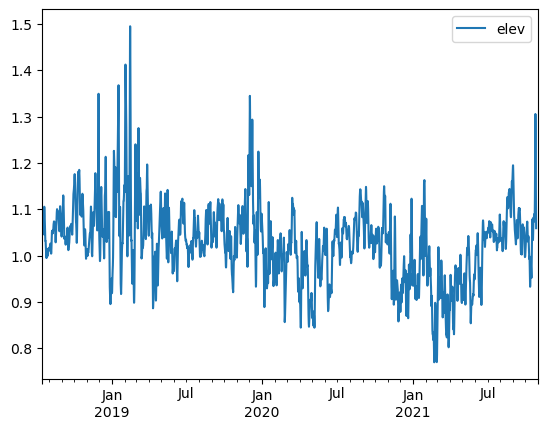

In [36]:
sffpx = sffpx_elev * M2FT
sffpx_subtide = cosine_lanczos(sffpx_elev, cutoff_period="40h")
#the filtering step we lose a bit on each end
sffpx_subtide = sffpx_subtide.resample("15min").ffill()
sffpx_subtide.plot()

In [37]:
oh4_astro_raw = pd.read_csv(
        astro_file,
        header=None,
        #sep=r"\s+",
        sep=r'\s{2,}',
        names=["datetime", "value"],
        engine="python",
    )
oh4_astro_raw
#needed to change the separator to be more than one space

,datetime,value
0,2001-01-01 00:00,4.3886
1,2001-01-01 00:15,4.2490
2,2001-01-01 00:30,4.1073
3,2001-01-01 00:45,3.9652
4,2001-01-01 01:00,3.8243
...,...,...
853723,2025-05-07 22:45,3.4678
853724,2025-05-07 23:00,3.5712
853725,2025-05-07 23:15,3.6769
853726,2025-05-07 23:30,3.7822


In [38]:
oh4_astro_raw_dt=oh4_astro_raw.copy()
oh4_astro_raw_dt["datetime"] = pd.to_datetime(
        oh4_astro_raw["datetime"], errors="coerce", format="%Y-%m-%d %H:%M"
    )
oh4_astro_raw_dt

,datetime,value
0,2001-01-01 00:00:00,4.3886
1,2001-01-01 00:15:00,4.2490
2,2001-01-01 00:30:00,4.1073
3,2001-01-01 00:45:00,3.9652
4,2001-01-01 01:00:00,3.8243
...,...,...
853723,2025-05-07 22:45:00,3.4678
853724,2025-05-07 23:00:00,3.5712
853725,2025-05-07 23:15:00,3.6769
853726,2025-05-07 23:30:00,3.7822


In [39]:
# If time is present in a second column-like token, fall back to generic parsing
if oh4_astro_raw_dt["datetime"].isna().any():
    oh4_astro_raw_dt["datetime"] = pd.to_datetime(
        oh4_astro_raw["datetime"].astype(str), errors="coerce"
    )
#oh4_astro_raw
oh4_astro = (
    oh4_astro_raw_dt.dropna(subset=["datetime"])
    .set_index("datetime")["value"]
    .astype(float)
    .asfreq("15min")
)

In [40]:
oh4_astro

datetime
2001-01-01 00:00:00    4.3886
2001-01-01 00:15:00    4.2490
2001-01-01 00:30:00    4.1073
2001-01-01 00:45:00    3.9652
2001-01-01 01:00:00    3.8243
                        ...  
2025-05-07 22:45:00    3.4678
2025-05-07 23:00:00    3.5712
2025-05-07 23:15:00    3.6769
2025-05-07 23:30:00    3.7822
2025-05-07 23:45:00    3.8863
Freq: 15min, Name: value, Length: 853728, dtype: float64

<Axes: >

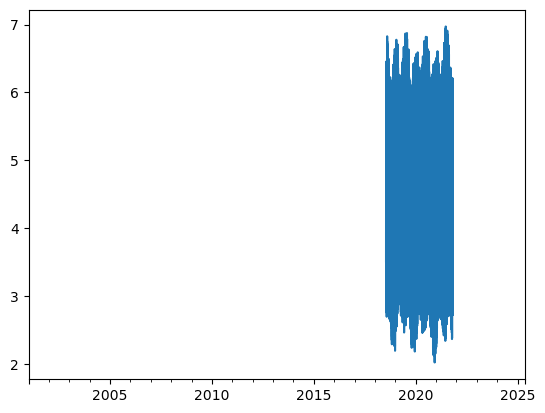

In [41]:
oh4_sub_predicted = sffpx_subtide * 0.9620 + 1.1513

best_shift = -10
oh4_sub_predicted = oh4_sub_predicted.shift(-best_shift).squeeze()
oh4_predicted = oh4_sub_predicted + oh4_astro - oh4_sub_predicted.mean()
oh4_predicted.plot()

In [42]:
sim_gate_height, zin_df = gen_gate_height(
        export_ts, priority, max_height, oh4_predicted, cvp_ts, inside_level0, s1, s2, dt
    )
sim_gate_height

,ccfb_height
2018-08-14 00:00:00,2.630710
2018-08-14 00:02:00,5.261420
2018-08-14 00:04:00,7.892129
2018-08-14 00:06:00,8.341523
2018-08-14 00:08:00,8.366076
...,...
2021-09-30 23:50:00,0.000000
2021-09-30 23:52:00,0.000000
2021-09-30 23:54:00,0.000000
2021-09-30 23:56:00,0.000000


In [43]:
height=sim_gate_height
plot=True

In [44]:
from bdschism.ccf_gate_height import remove_continuous_duplicates
import matplotlib.pyplot as plt

In [45]:
dest="./ccfb_gate_dated_2.th"

In [46]:
height_t = remove_continuous_duplicates(height, height.columns.tolist()[0])
height_t = height_t * FT2M
height_t.index.name = "datetime"
height_t.columns = ["height"]
dlen = len(height_t)
height_t.insert(0, "install", dlen * [1])
height_t.insert(1, "ndup", dlen * [5])
height_t.insert(2, "op_down", dlen * [1.0])
height_t.insert(3, "op_up", dlen * [0.0])
height_t.insert(4, "elev", dlen * [-4.0244])
height_t.insert(5, "width", dlen * [6.096])

print(f"Saving predicted gate height file to {dest}")
height_t[s1 : s2 + oneday].to_csv(
    dest,
    sep=" ",
    header=True,
    float_format="%.3f",
    date_format="%Y-%m-%dT%H:%M",
)


Saving predicted gate height file to ./ccfb_gate_dated_2.th


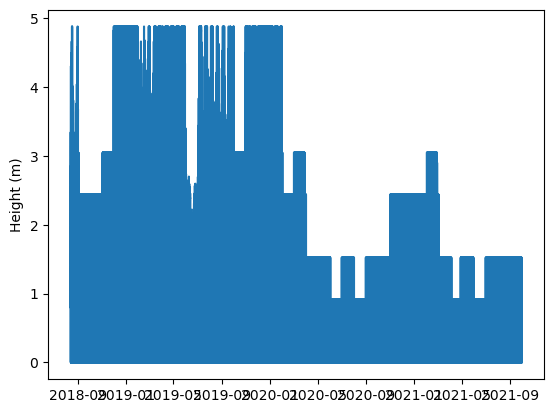

In [47]:
if plot:
    fig, (ax1) = plt.subplots(1, 1)
    lsyn = ax1.step(
        height_t.index,
        height_t["height"],
        where="post",
        label="ccfb gate height predicted",
    )
    ax1.set_ylabel("Height (m)")

In [9]:
#is this file the same as the one from 2 days ago?
first=pd.read_csv("/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_gate_dated_03_11.th",sep=r'\s')
second=pd.read_csv("/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_dated_2.th",sep=r'\s')
second

/scratch/jisrael/job_47317394/ipykernel_3294473/3409461185.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  first=pd.read_csv("/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_gate_dated_03_11.th",sep=r'\s')
/scratch/jisrael/job_47317394/ipykernel_3294473/3409461185.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  second=pd.read_csv("/home/jisrael/Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_dated_2.th",sep=r'\s')


,datetime,install,ndup,op_down,op_up,elev,width,height
0,2018-08-14T00:00,1,5,1.0,0.0,-4.024,6.096,0.802
1,2018-08-14T00:02,1,5,1.0,0.0,-4.024,6.096,1.604
2,2018-08-14T00:04,1,5,1.0,0.0,-4.024,6.096,2.406
3,2018-08-14T00:06,1,5,1.0,0.0,-4.024,6.096,2.591
4,2018-08-14T00:08,1,5,1.0,0.0,-4.024,6.096,2.602
...,...,...,...,...,...,...,...,...
142803,2021-09-30T02:40,1,5,1.0,0.0,-4.024,6.096,0.610
142804,2021-09-30T02:42,1,5,1.0,0.0,-4.024,6.096,0.914
142805,2021-09-30T06:00,1,5,1.0,0.0,-4.024,6.096,0.610
142806,2021-09-30T06:02,1,5,1.0,0.0,-4.024,6.096,0.305


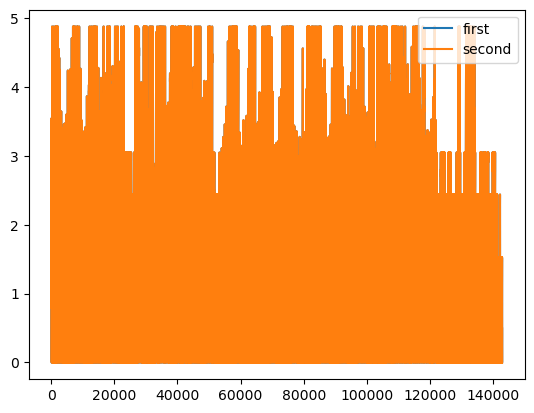

In [10]:
fig, ax =plt.subplots()
ax.plot(first.height,label='first')
ax.plot(second.height,label='second')
ax.legend()

# Other testing

In [ ]:

#     oh4_astro_raw = pd.read_csv(
#         astro_tide_file,
#         header=None,
#         sep=r"\s+",
#         names=["datetime", "value"],
#         engine="python",
#     )
#     oh4_astro_raw["datetime"] = pd.to_datetime(
#         oh4_astro_raw["datetime"], errors="coerce", format="%Y-%m-%d"
#     )
#     # If time is present in a second column-like token, fall back to generic parsing
#     if oh4_astro_raw["datetime"].isna().any():
#         oh4_astro_raw["datetime"] = pd.to_datetime(
#             oh4_astro_raw["datetime"].astype(str), errors="coerce"
#         )
#     oh4_astro = (
#         oh4_astro_raw.dropna(subset=["datetime"])
#         .set_index("datetime")["value"]
#         .astype(float)
#         .asfreq("15min")
#     )

#     ## linear regression of sffpx sub tide to oh4 sub tide
#     oh4_sub_predicted = sffpx_subtide * 0.9620 + 1.1513
#     best_shift = -10
#     oh4_sub_predicted = oh4_sub_predicted.shift(-best_shift).squeeze()
#     oh4_predicted = oh4_sub_predicted + oh4_astro - oh4_sub_predicted.mean()
#     return oh4_predicted[s1:s2]

In [ ]:
# sim_gate_height, zin_df = gen_gate_height(
#     export_ts, priority, max_height, oh4_predict, cvp_ts, inside_level0, s1, s2, dt
# )

The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to ./ccfb_gate_dated.th


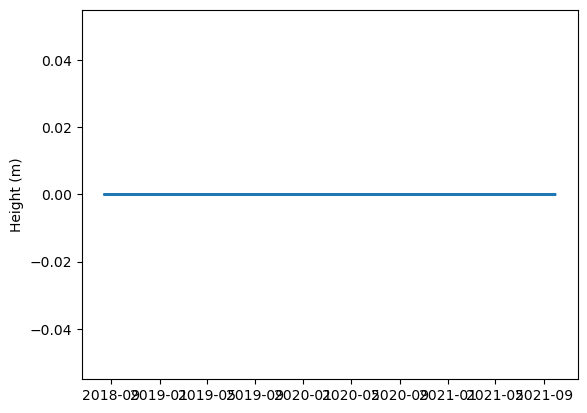

In [14]:
ccf_gate(
      model_start,
      model_end,
      "./ccfb_gate_dated.th",
      astro_file,
      export_file,
      sffpx_elev,
      plot=True,
)
#arguements are sdate, edate, dest, astro_file, export_file,sffpx_elev,plot=False, and save_intermediate=False


In [3]:
# sffpx_elev=sffpx_level(
#       model_start,
#       model_end,
#       sf_data_repo,
# )
# # ccf_gate(
# #       model_start,
# #       model_end,
# #       "./ccfb_gate_dated.th",
# #       astro_file,
# #       export_file,
# #       sffpx_elev,
# #       plot,
# # )


In [4]:
sffpx_elev

,elev


In [5]:
# Savio_scratch_back_up/scripts/preprocessing_scripts/ccfb_gate_dated.th

NameError: name 'Savio_scratch_back_up' is not defined

In [ ]:
sffpx_elev.index

In [6]:
test=pd.read_csv(astro_file,parse_dates=True,date_format="%Y-%m-%d %H:%M",header=None,sep=r'\s{2,}',index_col=0).squeeze()
test
# pd.read_csv(astro_file,parse_dates=True,index_col=0,dtype=float,date_format="%Y-%m-%d %H:%M",header=None,
# sep="\\s+").squeeze()#.asfreq("15min")

/scratch/jisrael/job_47163537/ipykernel_3267744/4163930326.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test=pd.read_csv(astro_file,parse_dates=True,date_format="%Y-%m-%d %H:%M",header=None,sep=r'\s{2,}',index_col=0).squeeze()


0
2001-01-01 00:00:00    4.3886
2001-01-01 00:15:00    4.2490
2001-01-01 00:30:00    4.1073
2001-01-01 00:45:00    3.9652
2001-01-01 01:00:00    3.8243
                        ...  
2025-05-07 22:45:00    3.4678
2025-05-07 23:00:00    3.5712
2025-05-07 23:15:00    3.6769
2025-05-07 23:30:00    3.7822
2025-05-07 23:45:00    3.8863
Name: 1, Length: 853728, dtype: float64

In [7]:
test2=pd.read_csv(astro_file,parse_dates=True,date_format="%Y-%m-%d %H:%M",header=None,sep=r'\s{2,}',index_col=0).squeeze().asfreq("15min")

/scratch/jisrael/job_47163537/ipykernel_3267744/2509981659.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test2=pd.read_csv(astro_file,parse_dates=True,date_format="%Y-%m-%d %H:%M",header=None,sep=r'\s{2,}',index_col=0).squeeze().asfreq("15min")


In [8]:
test2

0
2001-01-01 00:00:00    4.3886
2001-01-01 00:15:00    4.2490
2001-01-01 00:30:00    4.1073
2001-01-01 00:45:00    3.9652
2001-01-01 01:00:00    3.8243
                        ...  
2025-05-07 22:45:00    3.4678
2025-05-07 23:00:00    3.5712
2025-05-07 23:15:00    3.6769
2025-05-07 23:30:00    3.7822
2025-05-07 23:45:00    3.8863
Freq: 15min, Name: 1, Length: 853728, dtype: float64

In [9]:
from dms_datastore.read_multi import read_ts_repo, infer_source_priority

In [10]:
#read_ts_repo("sffpx", "elev", repo=sf_data_repo, src_priority="infer")

,value


In [12]:
testts=read_ts_repo("sffpx", "elev", repo=sf_data_repo, src_priority="infer",start=s1-2*margin, end=s2+2*margin)

In [13]:
if testts.isnull().any().any():
    print('missing')

missing


In [14]:
infer_source_priority("sffpx")

['noaa']

In [15]:
testts

,value
2018-06-15 00:00:00,2.237
2018-06-15 00:06:00,2.208
2018-06-15 00:12:00,2.177
2018-06-15 00:18:00,2.159
2018-06-15 00:24:00,2.155
...,...
2021-11-29 23:36:00,0.514
2021-11-29 23:42:00,0.492
2021-11-29 23:48:00,0.473
2021-11-29 23:54:00,0.458


In [16]:
testpred=read_ts_repo(
        "sffpx", "predictions", repo=sf_data_repo, src_priority="infer",start=s1-2*margin, end=s2+2*margin)

In [17]:
if testpred.isnull().any().any():
    print('missing')

In [18]:
testpred

,value
2018-06-15 00:00:00,2.063
2018-06-15 00:06:00,2.051
2018-06-15 00:12:00,2.036
2018-06-15 00:18:00,2.019
2018-06-15 00:24:00,1.999
...,...
2021-11-29 23:36:00,0.514
2021-11-29 23:42:00,0.494
2021-11-29 23:48:00,0.474
2021-11-29 23:54:00,0.456


In [19]:
ts_df = testts.combine_first(testpred)
ts_df

,value
2018-06-15 00:00:00,2.237
2018-06-15 00:06:00,2.208
2018-06-15 00:12:00,2.177
2018-06-15 00:18:00,2.159
2018-06-15 00:24:00,2.155
...,...
2021-11-29 23:36:00,0.514
2021-11-29 23:42:00,0.492
2021-11-29 23:48:00,0.473
2021-11-29 23:54:00,0.458


In [24]:
# Shift for SCHISM time zone
shift_h = dtm.timedelta(hours=8.5)
position_shift = int(shift_h / ts_df.index.freq)
ts_df = ts_df.shift(position_shift)
ts_df = ts_df.loc[s1 - margin : s2 + margin]

In [23]:
if ts_df.isnull().any().any():
    print('missing')

In [25]:
ts_df.index.freq

<6 * Minutes>

In [26]:
ts_df

,value
2018-07-15 00:00:00,NaN
2018-07-15 00:06:00,NaN
2018-07-15 00:12:00,NaN
2018-07-15 00:18:00,NaN
2018-07-15 00:24:00,NaN
...,...
2021-10-30 23:36:00,1.484
2021-10-30 23:42:00,1.502
2021-10-30 23:48:00,1.517
2021-10-30 23:54:00,1.528


In [ ]:
ts_df.columns = ["elev"]
sffpx_elev=ts_df.copy()

In [ ]:
sffpx_elev

The input export dt is Daily
Making priorities from tide
Saving predicted gate height file to ./ccfb_gate_dated.th
